# import libraries and load data

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ssssws/spam-email-detection-dataset-clean-and-ml-ready/spam_email_dataset.csv')
df.shape

(10000, 20)

# A quick overview of this dataset

Despite of all the info from the data card - 

## Q1: How many senders are in this dataset, and what are their domain? Are there any information in their domain?

In [3]:
len(df['sender_email'].unique())

10000

In [4]:
len(df['sender_domain'].unique())

8

In [5]:
df['sender_domain'].unique()

array(['outlook.com', 'company.com', 'unknownmail.cc', 'chealdealz.xyz',
       'yahoo.com', 'gmail.com', 'freemoney.biz', 'winbignow.ru'],
      dtype=object)

In [6]:
df.groupby('sender_domain')['sender_reputation_score'].describe()

,count,mean,std,min,25%,50%,75%,max
sender_domain,,,,,,,,
chealdealz.xyz,1028.0,0.586994,0.157979,0.3,0.46,0.59,0.72,0.85
company.com,1454.0,0.753611,0.145032,0.5,0.63,0.76,0.88,1.00
freemoney.biz,1004.0,0.567620,0.159220,0.3,0.42,0.57,0.71,0.85
gmail.com,1531.0,0.753534,0.141370,0.5,0.64,0.75,0.87,1.00
outlook.com,1466.0,0.752449,0.146725,0.5,0.62,0.75,0.88,1.00
unknownmail.cc,989.0,0.577624,0.157616,0.3,0.44,0.58,0.71,0.85
winbignow.ru,974.0,0.574425,0.160404,0.3,0.44,0.57,0.71,0.85
yahoo.com,1554.0,0.748481,0.142289,0.5,0.62,0.75,0.87,1.00


In [7]:
df.groupby('sender_domain')['label'].mean()

sender_domain
chealdealz.xyz    1.0
company.com       0.0
freemoney.biz     1.0
gmail.com         0.0
outlook.com       0.0
unknownmail.cc    1.0
winbignow.ru      1.0
yahoo.com         0.0
Name: label, dtype: float64

In [8]:
df.groupby('sender_domain').size()

sender_domain
chealdealz.xyz    1028
company.com       1454
freemoney.biz     1004
gmail.com         1531
outlook.com       1466
unknownmail.cc     989
winbignow.ru       974
yahoo.com         1554
dtype: int64

In [9]:
df_domain = pd.get_dummies(df['sender_domain'])
y = df['label']

In [10]:
lr_model = LogisticRegression()
cross_val_score(lr_model, df_domain, y, scoring = 'roc_auc')

array([1., 1., 1., 1., 1.])

In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(df_domain, y)

lr_model.fit(X_tr, y_tr)
y_pred = lr_model.predict(X_te)

confusion_matrix(y_pred, y_te)

array([[1495,    0],
       [   0, 1005]])

It seems like our model can distinguish the spam and normal emails just by domain names, which is rare in real life. So let's move a step further - 

# Q2. What are some characteristics in spam emails?

In [12]:
vectorizer = CountVectorizer(stop_words='english', min_df=5)
X = vectorizer.fit_transform(df['email_text'])
chi_scores, _ = chi2(X, df['label'])

top_spam_words = [vectorizer.get_feature_names_out()[i] 
                  for i in chi_scores.argsort()[-10:]]
top_spam_reversed = []
for i in range(len(top_spam_words)-1, -1, -1):
    top_spam_reversed.append(top_spam_words[i])

print(f'Top 10 most discrimitive words: {', '.join(top_spam_reversed)}')

Top 10 most discrimitive words: urgent, guarantee, limited, win, click, cash, offer, free, schedule, sync


In [13]:
n_spam = df.loc[df['label']==1].shape[0]
n_normal = df.loc[df['label']==0].shape[0]
for w in top_spam_reversed:
    n_in_spam = df.loc[df['label']==1, 'email_text'].str.contains(w, case=False).sum()
    n_in_normal =  df.loc[df['label']==0, 'email_text'].str.contains(w, case=False).sum()
    print(f'Percentage of "{w}" in spam: {n_in_spam/n_spam}')
    print(f'Percentage of "{w}" in ham: {n_in_normal/n_normal}')
    print('--------------------------------------------------')

Percentage of "urgent" in spam: 0.7198998748435544
Percentage of "urgent" in ham: 0.0
--------------------------------------------------
Percentage of "guarantee" in spam: 0.7181476846057572
Percentage of "guarantee" in ham: 0.0
--------------------------------------------------
Percentage of "limited" in spam: 0.7143929912390488
Percentage of "limited" in ham: 0.0
--------------------------------------------------
Percentage of "win" in spam: 0.7196495619524406
Percentage of "win" in ham: 0.041465445462114905
--------------------------------------------------
Percentage of "click" in spam: 0.7036295369211515
Percentage of "click" in ham: 0.0
--------------------------------------------------
Percentage of "cash" in spam: 0.7076345431789737
Percentage of "cash" in ham: 0.0
--------------------------------------------------
Percentage of "offer" in spam: 0.7236545682102629
Percentage of "offer" in ham: 0.011823480432972523
--------------------------------------------------
Percentage of

# Q3. Can we visualize the clusters between spam and ham?

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

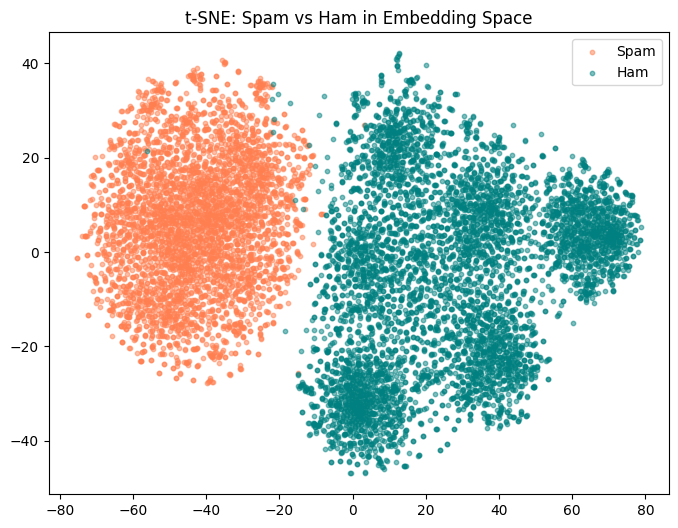

In [14]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['email_text'].tolist())

tsne = TSNE(n_components=2, random_state=42)
embed_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embed_2d[df['label']==1, 0], embed_2d[df['label']==1, 1], 
            c='coral', alpha=0.5, label='Spam', s=10)
plt.scatter(embed_2d[df['label']==0, 0], embed_2d[df['label']==0, 1], 
            c='teal', alpha=0.5, label='Ham', s=10)
plt.legend()
plt.title('t-SNE: Spam vs Ham in Embedding Space')
plt.show()